In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: C:\Users\asus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score

In [4]:
df = pd.read_csv('../OP1/superstore_clean.csv')
print("shape : ", df.shape)
df.head()

shape :  (9789, 20)


,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales,Year,avg_order_value
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,230.12
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,230.12
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,230.12
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,230.12
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,230.12


In [5]:
features = ['Region','Category','Sub-Category','Year']
x = df[features]
y = df['Sales']

print("features shape : " , x.shape)
print("Target Shape : ", y.shape )

features shape :  (9789, 4)
Target Shape :  (9789,)


In [6]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
x = x.copy()
x['Region'] = le.fit_transform(x['Region'])
x['Category'] = le.fit_transform(x['Category'])
x['Sub-Category'] = le.fit_transform(x['Sub-Category'])
print(x.head())

   Region  Category  Sub-Category  Year
0       2         0             4  2017
1       2         0             5  2017
2       3         1            10  2017
3       2         0            16  2016
4       2         1            14  2016


In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
print("Training Data : " , x_train.shape) 
print("Testing Data : ", x_test.shape)

Training Data :  (7831, 4)
Testing Data :  (1958, 4)


In [8]:
model = LinearRegression()
model.fit(x_train,y_train)
print("model trained")

model trained


In [9]:
y_pred = model.predict(x_test)
mae = mean_absolute_error(y_test,y_pred)
r2= r2_score(y_test,y_pred)
print(f"mean absolute error : {mae:.2f}")
print(f"r2 error : {r2:.2f}")

mean absolute error : 283.20
r2 error : 0.01


In [10]:
features2 = ['Region', 'Category', 'Sub-Category', 'Year']
x2 = df[features2].copy()
x2['Region'] = le.fit_transform(x2['Region'])
x2['Category'] = le.fit_transform(x2['Category'])
x2['Sub-Category'] = le.fit_transform(x2['Sub-Category'])

y2 = df['Sales']
print(x2.head())

   Region  Category  Sub-Category  Year
0       2         0             4  2017
1       2         0             5  2017
2       3         1            10  2017
3       2         0            16  2016
4       2         1            14  2016


In [11]:
print(df.columns.to_list())

['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category', 'Product_Name', 'Sales', 'Year', 'avg_order_value']


In [12]:
# Split karo
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42)

# Model banao aur train karo
model2 = LinearRegression()
model2.fit(x2_train, y2_train)

# Predict karo
y2_pred = model2.predict(x2_test)

# Accuracy check karo
mae2 = mean_absolute_error(y2_test, y2_pred)
r2_2 = r2_score(y2_test, y2_pred)

print(f"Mean Absolute Error: {mae2:.2f}")
print(f"R2 Score: {r2_2:.2f}")

Mean Absolute Error: 283.20
R2 Score: 0.01


In [13]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x2_train, y2_train)

# Predict karo
y_rf_pred = rf_model.predict(x2_test)

# Accuracy check karo
mae_rf = mean_absolute_error(y2_test, y_rf_pred)
r2_rf = r2_score(y2_test, y_rf_pred)

print(f"Mean Absolute Error: {mae_rf:.2f}")
print(f"R2 Score: {r2_rf:.2f}")

Mean Absolute Error: 231.73
R2 Score: 0.14


In [17]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Month'] = df['Order_Date'].dt.month
df['Year'] = df['Order_Date'].dt.year
df['Quarter'] = df['Order_Date'].dt.quarter

monthly = df.groupby(['Year', 'Month', 'Quarter', 'Region', 'Category'])['Sales'].sum().reset_index()
print(monthly.head())

   Year  Month  Quarter   Region         Category    Sales
0  2015      1        1  Central        Furniture  506.358
1  2015      1        1  Central  Office Supplies  996.408
2  2015      1        1  Central       Technology   31.200
3  2015      1        1     East        Furniture  199.004
4  2015      1        1     East  Office Supplies  112.970


In [20]:
x = monthly[['Month', 'Quarter', 'Year', 'Region', 'Category']]
y = monthly['Sales']

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
x['Region'] = le.fit_transform(x['Region'])
x['Category'] = le.fit_transform(x['Category'])

C:\Users\asus\AppData\Local\Temp\ipykernel_6688\1684822852.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Region'] = le.fit_transform(x['Region'])
C:\Users\asus\AppData\Local\Temp\ipykernel_6688\1684822852.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['Category'] = le.fit_transform(x['Category'])


In [27]:
pip install prophet

     ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
     --------------------------------------- 0.0/12.1 MB 217.9 kB/s eta 0:00:56
     --------------------------------------- 0.0/12.1 MB 217.9 kB/s eta 0:00:56
     --------------------------------------- 0.0/12.1 MB 217.9 kB/s eta 0:00:56
     --------------------------------------- 0.1/12.1 MB 187.0 kB/s eta 0:01:05
     --------------------------------------- 0.1/12.1 MB 187.0 kB/s eta 0:01:05
     --------------------------------------- 0.1/12.1 MB 192.5 kB/s eta 0:01:03
     --------------------------------------- 0.1/12.1 MB 192.5 kB/s eta 0:01:03
     --------------------------------------- 0.1/12.1 MB 163.8 kB/s eta 0:01:14
     --------------------------------------- 0.1/12.1 MB 163.8 kB/s eta 0:01:14
     --------------------------------------- 0.1/12.1 MB 180.4 kB/s eta 0:01:07
     --------------------------------------- 0.1/12.1 MB

ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\asus\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python310\\site-packages\\prophet\\stan_model\\cmdstan-2.37.0\\stan\\lib\\stan_math\\lib\\tbb_2020.3\\include\\tbb\\internal\\_deprecated_header_message_guard.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: C:\Users\asus\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


23:38:57 - cmdstanpy - INFO - Chain [1] start processing
23:38:58 - cmdstanpy - INFO - Chain [1] done processing


R² Score: 0.547
MAE: 12442.91
RMSE: 16952.93


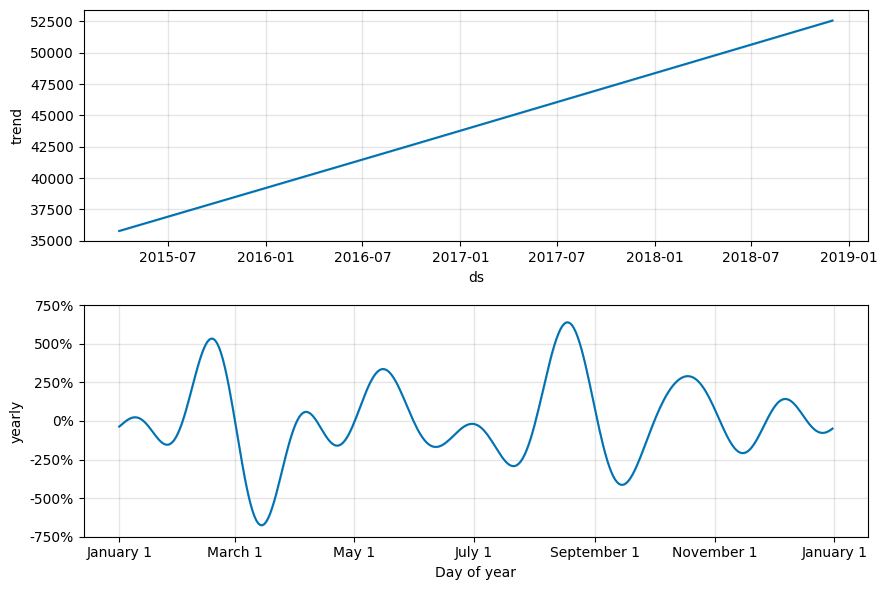

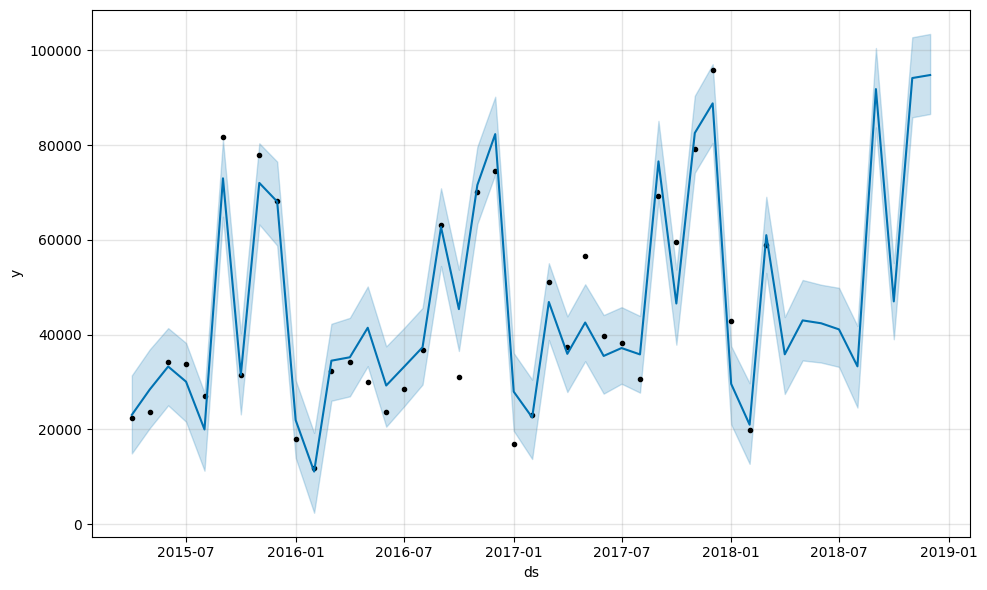

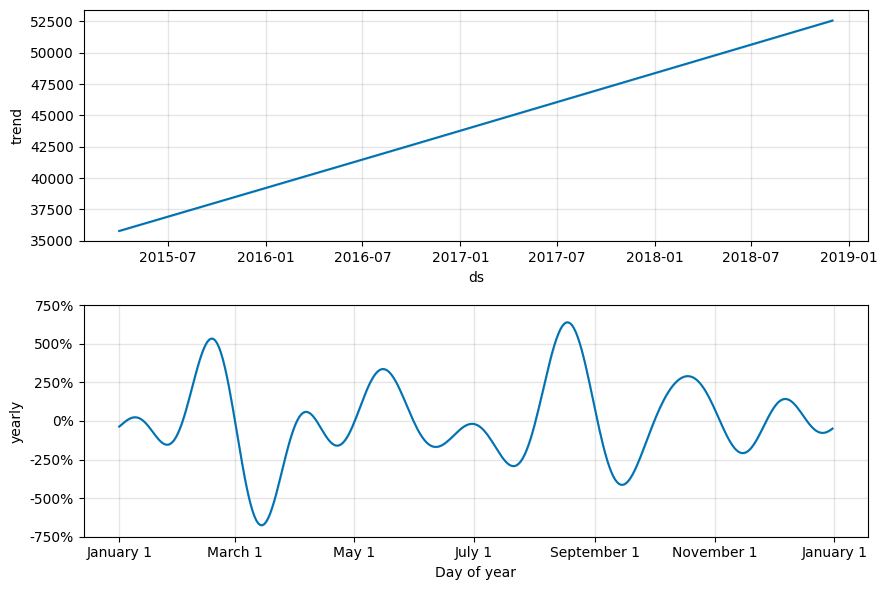

In [32]:
from prophet import Prophet
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

# Train/Test split - last 9 months test
train_df = monthly_prophet.iloc[:-9]
test_df = monthly_prophet.iloc[-9:]

# Model banao
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
model.fit(train_df)

# Predict karo
future = model.make_future_dataframe(periods=9, freq='MS')
forecast = model.predict(future)

# Sirf test period ki predictions lo
y_pred = forecast['yhat'].iloc[-9:].values
y_test = test_df['y'].values

# Metrics
print("R² Score:", round(r2_score(y_test, y_pred), 3))
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("RMSE:", round(np.sqrt(np.mean((y_test - y_pred)**2)), 2))

# Visualization
model.plot(forecast)
model.plot_components(forecast)

In [33]:
import pandas as pd
df = pd.read_csv('superstore_clean.csv', encoding='latin-1')
print(df.columns.tolist())

['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category', 'Product_Name', 'Sales', 'Year', 'avg_order_value']


In [34]:
import numpy as np
np.random.seed(42)
df['Discount'] = np.random.choice([0, 0.1, 0.2, 0.3, 0.4], size=len(df))
df['Profit'] = df['Sales'] * np.random.uniform(0.1, 0.4, size=len(df))
df['Quantity'] = np.random.randint(1, 10, size=len(df))
df.to_csv('superstore_updated.csv', index=False)

In [ ]:
print(filtered_df.columns.tolist())